In [4]:
pip install openml numpy pandas scikit-learn matplotlib seaborn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.3 MB 6.3 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.3 MB 6.5 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.3 MB 6.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.3 MB 7.3 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.3 MB 7.8 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 7.8 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 7.8 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.3 MB 5.6 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# %% Section 1: Data Loading and Initialization
import openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from greedy_algorithm.greedy import (
    greedy_submodular_maximization_2, 
    facility_location_score, 
    saturated_coverage_score
)


In [2]:
print("Fetching Bioresponse dataset from OpenML...")
dataset = openml.datasets.get_dataset("Bioresponse")
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute, dataset_format='dataframe')
y = y.astype(int).values  # Ensure binary targets are numeric integers

# Perform clean split to secure experimental partitions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)

# Set uniform optimization tracking constraints
budget_k = 50
steps = np.arange(1, budget_k + 1)

Fetching Bioresponse dataset from OpenML...


In [4]:
# %% Section 2: Mathematical Bounds Helper Function
def compute_online_upper_bound(S, sim_matrix, k):
    """Calculates the data-dependent online upper bound for Facility Location."""
    curr_score = facility_location_score(S, sim_matrix)
    all_gains = []
    for v in range(sim_matrix.shape[0]):
        if v in S: 
            continue
        all_gains.append(facility_location_score(S + [v], sim_matrix) - curr_score)
    top_k_gains = sorted(all_gains, reverse=True)[:k]
    return curr_score + sum(top_k_gains)

### Nowy ten pierwszy wykres, nie zdazylam go osobno dac, albo jakos uladnic, ale to to co prosił z porównaniem z online mathematical bound (empirical bound)


--- Processing Submodular Characterization for COLUMNS (Features) ---
Computing absolute Pearson correlation matrix for features...
Starting greedy selection using facility_location (k=50)...
Step 1: Selected element 504, Marginal Gain: 361.8194
Step 10: Selected element 658, Marginal Gain: 17.6916
Step 20: Selected element 277, Marginal Gain: 6.2379
Step 30: Selected element 216, Marginal Gain: 4.2274
Step 40: Selected element 605, Marginal Gain: 3.1115
Step 50: Selected element 451, Marginal Gain: 2.4709
Starting greedy selection using saturated_coverage (k=50)...
Step 1: Selected element 504, Marginal Gain: 361.8194
Step 10: Selected element 4, Marginal Gain: 30.5379
Step 20: Selected element 107, Marginal Gain: 3.8996
Step 30: Selected element 13, Marginal Gain: 0.7774
Step 40: Selected element 7, Marginal Gain: 0.0582
Step 50: Selected element 20, Marginal Gain: 0.0000

SUBMODULAR THEORETICAL BOUNDS FOR COLUMNS (Facility Location):
Greedy Solution Score:              962.6420
Dat

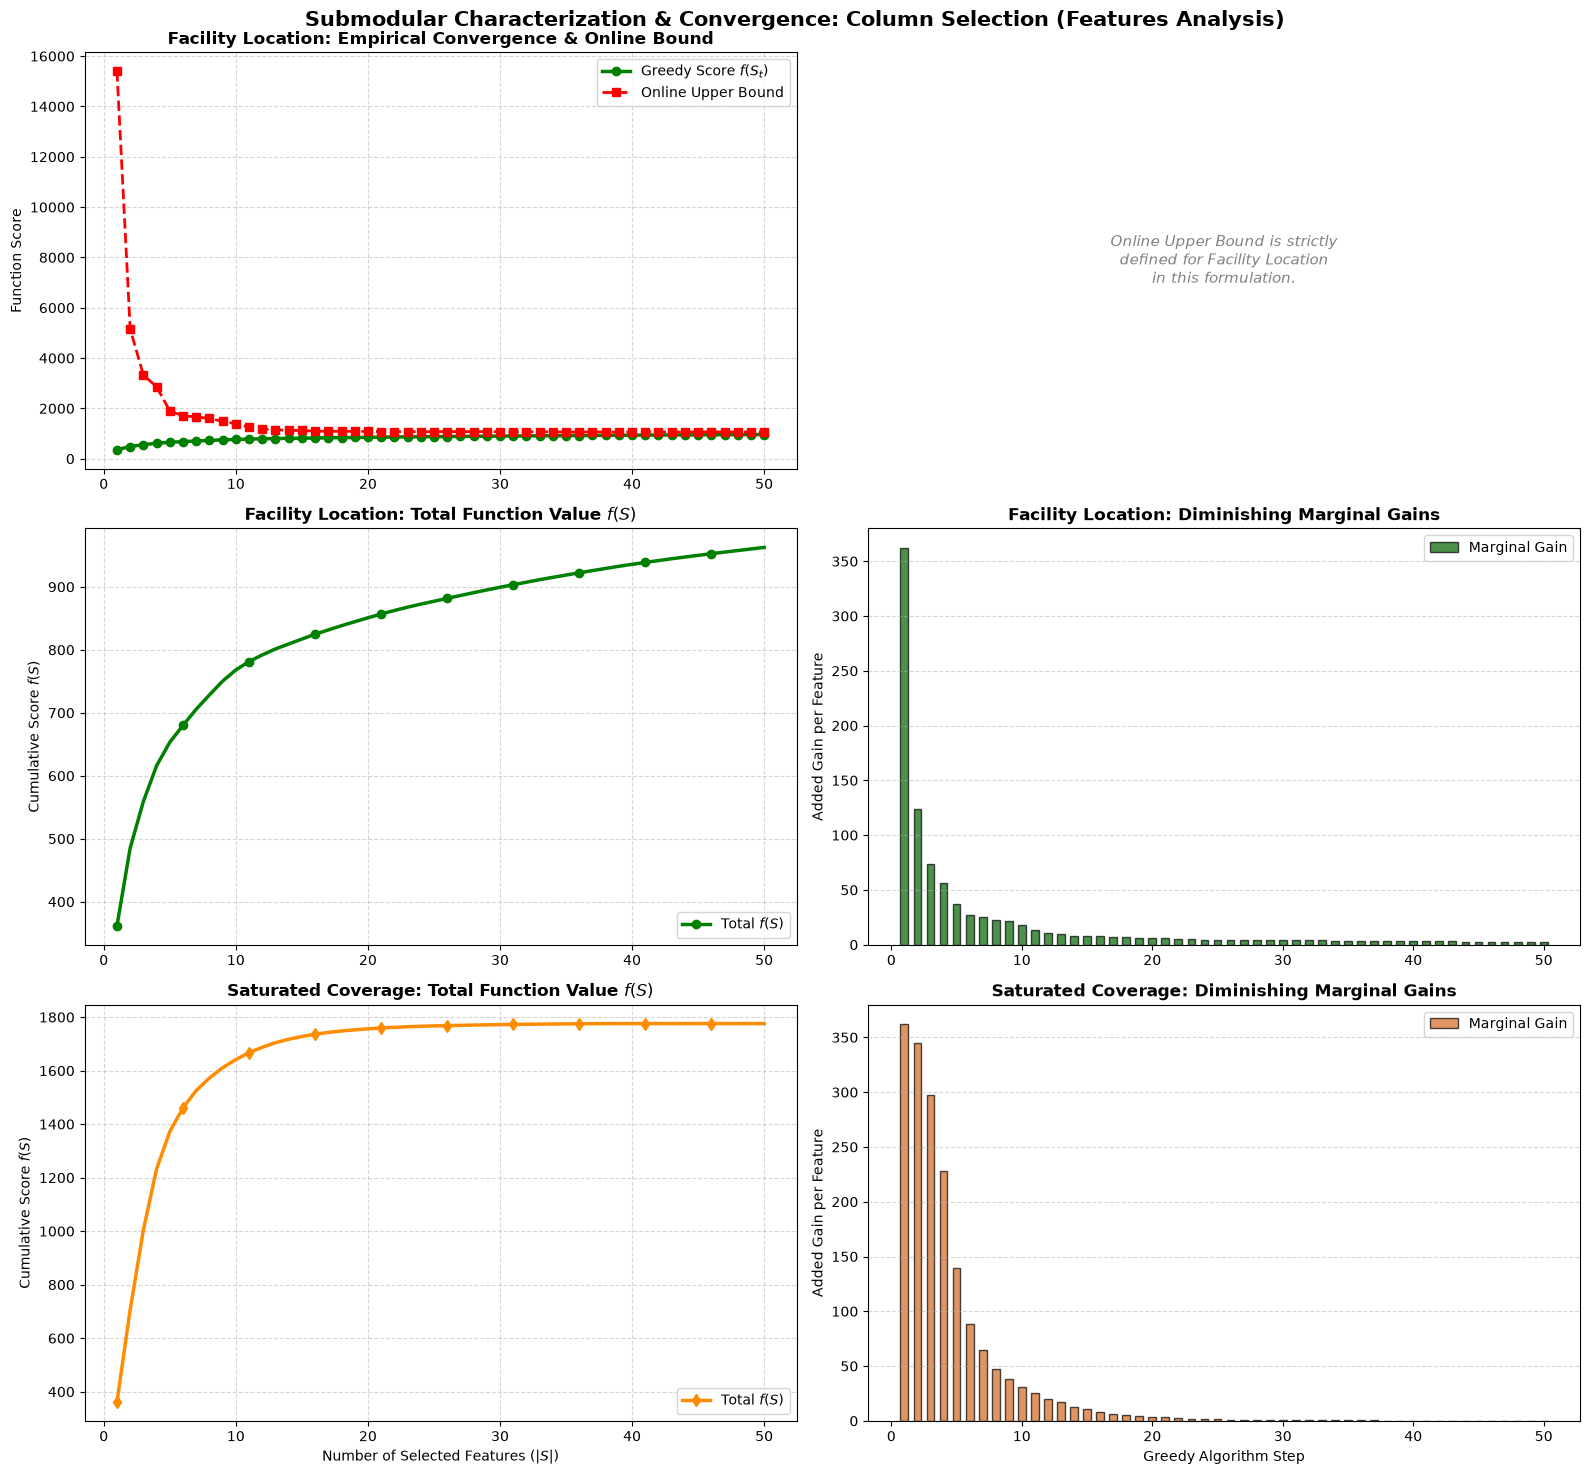


--- Processing Submodular Characterization for ROWS (Instances) ---
Computing absolute Cosine Similarity matrix for instances...
Starting greedy selection using facility_location (k=50)...
Step 1: Selected element 2074, Marginal Gain: 1549.2607
Step 10: Selected element 2981, Marginal Gain: 18.2283
Step 20: Selected element 2482, Marginal Gain: 8.2106
Step 30: Selected element 64, Marginal Gain: 6.1936
Step 40: Selected element 391, Marginal Gain: 4.5449
Step 50: Selected element 24, Marginal Gain: 3.3010
Starting greedy selection using saturated_coverage (k=50)...
Step 1: Selected element 2074, Marginal Gain: 1549.2607
Step 10: Selected element 6, Marginal Gain: 0.0000
Step 20: Selected element 16, Marginal Gain: 0.0000
Step 30: Selected element 26, Marginal Gain: 0.0000
Step 40: Selected element 36, Marginal Gain: 0.0000
Step 50: Selected element 46, Marginal Gain: 0.0000

SUBMODULAR THEORETICAL BOUNDS FOR ROWS (Facility Location):
Greedy Solution Score:              2324.2977
Data-

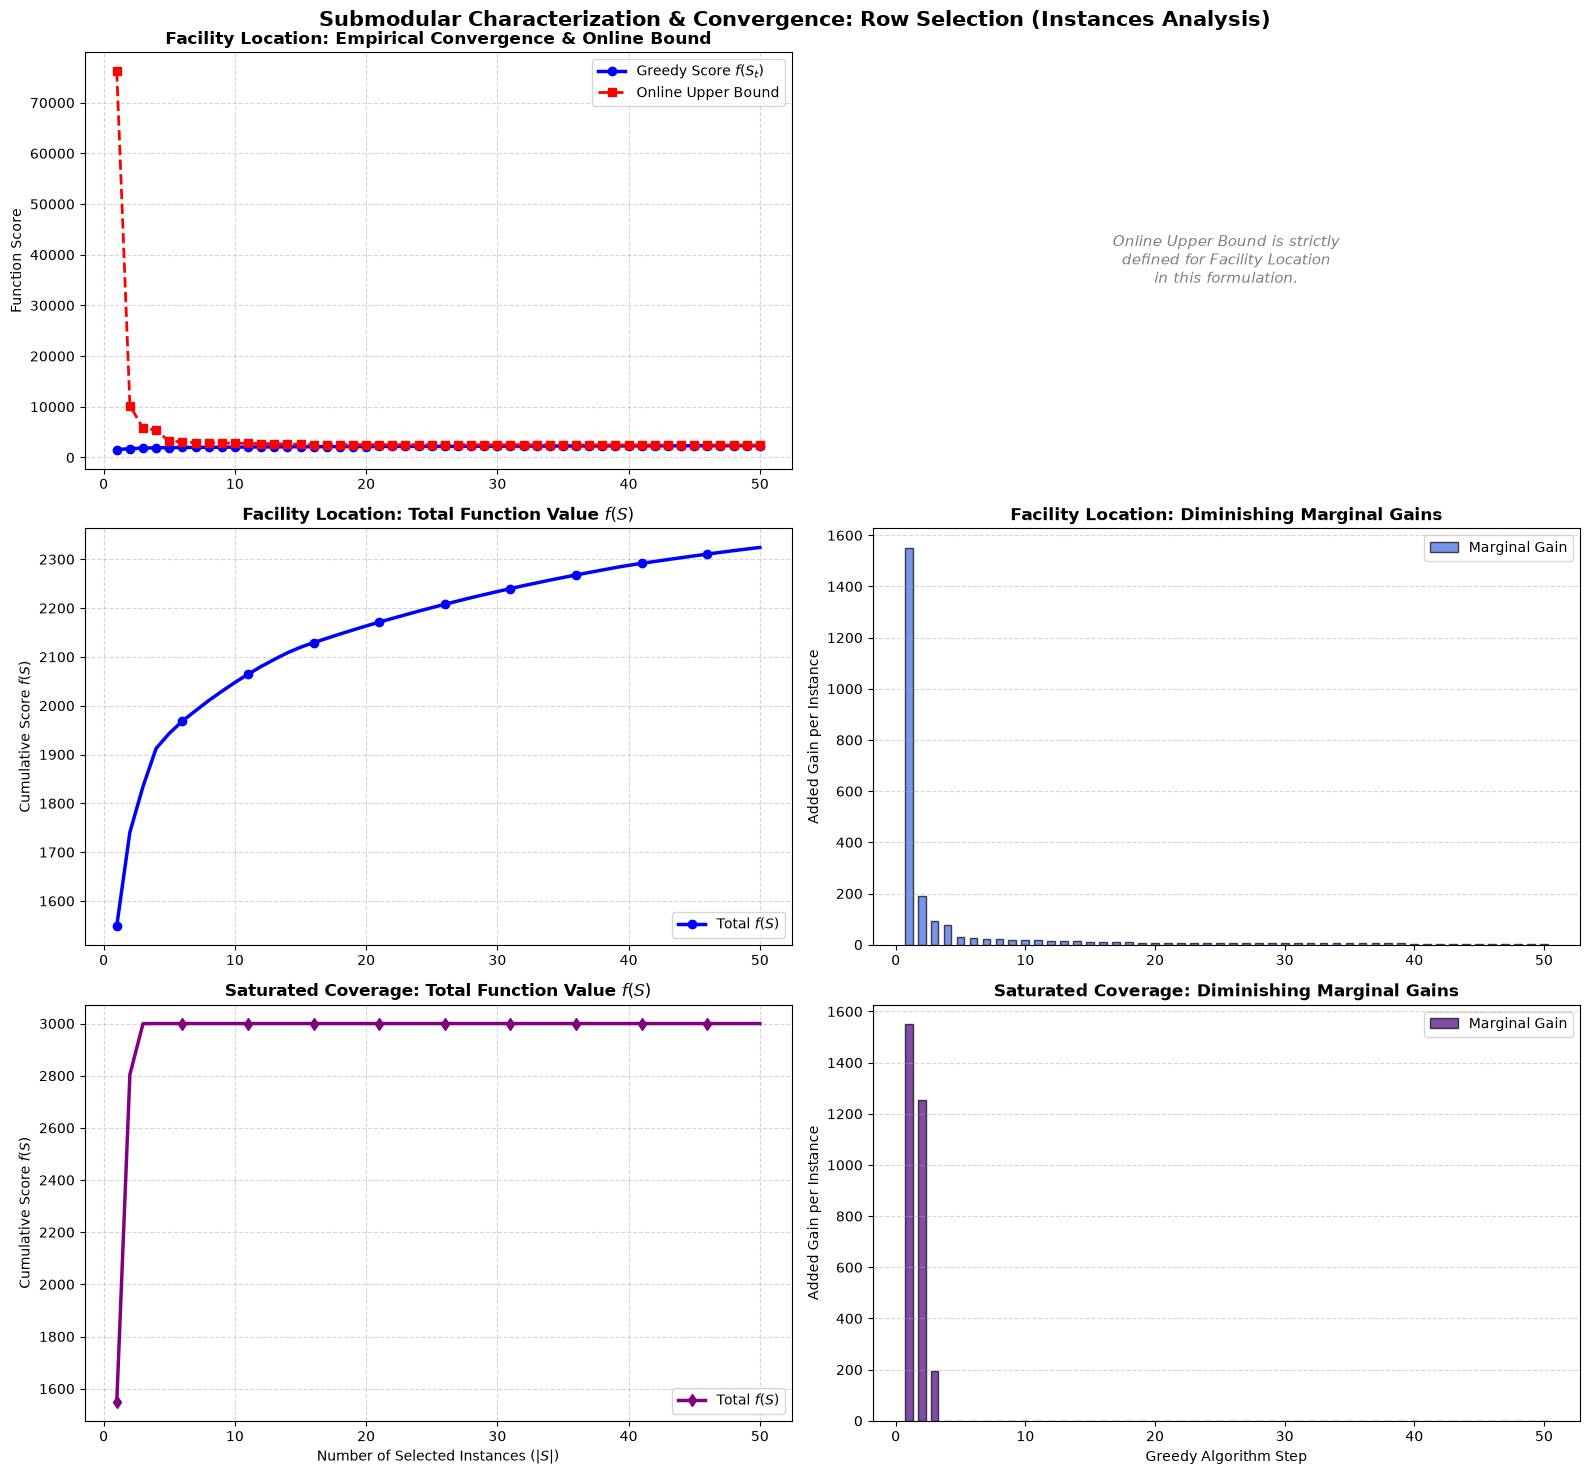

In [5]:
# =====================================================================
# %% Section 3: PART 1 - COLUMNS SELECTION (FEATURES CHARACTERIZATION)
# =====================================================================
print("\n--- Processing Submodular Characterization for COLUMNS (Features) ---")

# 1. Compute absolute Pearson correlation matrix across features
print("Computing absolute Pearson correlation matrix for features...")
bio_sim_matrix_cols = np.abs(np.corrcoef(X_train_np.T))
np.nan_to_num(bio_sim_matrix_cols, copy=False, nan=0.0)
np.fill_diagonal(bio_sim_matrix_cols, 1.0)

V_SIZE_COLS = bio_sim_matrix_cols.shape[0]

# 2. Run greedy optimizations - Odbieramy po 3 zmienne z obu wywołań!
selected_fl_cols, gains_fl_cols, bounds_fl_cols = greedy_submodular_maximization_2(
    V_SIZE_COLS, budget_k, bio_sim_matrix_cols, score_type='facility_location'
)
selected_sc_cols, gains_sc_cols, _ = greedy_submodular_maximization_2(
    V_SIZE_COLS, budget_k, bio_sim_matrix_cols, score_type='saturated_coverage', alpha=1.0
)

# 3. Compute structural limits and offline guarantees
ub_fac_loc_cols = compute_online_upper_bound(selected_fl_cols, bio_sim_matrix_cols, budget_k)
nemhauser_ub_cols = facility_location_score(selected_fl_cols, bio_sim_matrix_cols) / (1 - (1 / np.e))

print("\n" + "="*60)
print("SUBMODULAR THEORETICAL BOUNDS FOR COLUMNS (Facility Location):")
print(f"Greedy Solution Score:              {facility_location_score(selected_fl_cols, bio_sim_matrix_cols):.4f}")
print(f"Data-Dependent Online Upper Bound:  {ub_fac_loc_cols:.4f} (Tightest possible bound)")
print(f"Nemhauser Offline Upper Bound:     {nemhauser_ub_cols:.4f}")
print("="*60)

# 4. Reconstruct step-by-step utility growth metrics
total_utility_fl_cols = []
total_utility_sc_cols = []

for step in range(1, budget_k + 1):
    sub_fl = selected_fl_cols[:step]
    sub_sc = selected_sc_cols[:step]
    total_utility_fl_cols.append(facility_location_score(sub_fl, bio_sim_matrix_cols))
    total_utility_sc_cols.append(saturated_coverage_score(sub_sc, bio_sim_matrix_cols, alpha=1.0))

# 5. Render Expanded Plot Suite 1: Columns Characterization (Siatka 3x2)
fig1, axes1 = plt.subplots(3, 2, figsize=(16, 15))
fig1.suptitle("Submodular Characterization & Convergence: Column Selection (Features Analysis)", fontsize=15, fontweight='bold', y=0.98)

# RZĄD 1: Zbieżność empiryczna do sufitu teoretycznego (Wykres porównawczy)
axes1[0, 0].plot(steps, total_utility_fl_cols, marker='o', color='green', linewidth=2.5, label='Greedy Score $f(S_t)$')
axes1[0, 0].plot(steps, bounds_fl_cols, marker='s', color='red', linestyle='--', linewidth=2.0, label='Online Upper Bound')
axes1[0, 0].set_title("Facility Location: Empirical Convergence & Online Bound", fontsize=12, fontweight='bold')
axes1[0, 0].set_ylabel("Function Score")
axes1[0, 0].grid(True, linestyle='--', alpha=0.5)
axes1[0, 0].legend(loc='best')

axes1[0, 1].axis('off')
axes1[0, 1].text(0.5, 0.5, "Online Upper Bound is strictly\ndefined for Facility Location\nin this formulation.", 
                 ha='center', va='center', fontsize=11, style='italic', color='gray')

# RZĄD 2: Facility Location (Skumulowana wartość i przyrosty marginalne)
axes1[1, 0].plot(steps, total_utility_fl_cols, color='green', linewidth=2.5, marker='o', markevery=5, label='Total $f(S)$')
axes1[1, 0].set_title("Facility Location: Total Function Value $f(S)$", fontsize=12, fontweight='bold')
axes1[1, 0].set_ylabel("Cumulative Score $f(S)$")
axes1[1, 0].grid(True, linestyle='--', alpha=0.5)
axes1[1, 0].legend(loc='lower right')

axes1[1, 1].bar(steps, gains_fl_cols, color='darkgreen', alpha=0.7, edgecolor='black', width=0.6, label='Marginal Gain')
axes1[1, 1].set_title("Facility Location: Diminishing Marginal Gains", fontsize=12, fontweight='bold')
axes1[1, 1].set_ylabel("Added Gain per Feature")
axes1[1, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes1[1, 1].legend(loc='upper right')

# RZĄD 3: Saturated Coverage (Skumulowana wartość i przyrosty marginalne)
axes1[2, 0].plot(steps, total_utility_sc_cols, color='darkorange', linewidth=2.5, marker='d', markevery=5, label='Total $f(S)$')
axes1[2, 0].set_title("Saturated Coverage: Total Function Value $f(S)$", fontsize=12, fontweight='bold')
axes1[2, 0].set_xlabel("Number of Selected Features ($|S|$)")
axes1[2, 0].set_ylabel("Cumulative Score $f(S)$")
axes1[2, 0].grid(True, linestyle='--', alpha=0.5)
axes1[2, 0].legend(loc='lower right')

axes1[2, 1].bar(steps, gains_sc_cols, color='chocolate', alpha=0.7, edgecolor='black', width=0.6, label='Marginal Gain')
axes1[2, 1].set_title("Saturated Coverage: Diminishing Marginal Gains", fontsize=12, fontweight='bold')
axes1[2, 1].set_xlabel("Greedy Algorithm Step")
axes1[2, 1].set_ylabel("Added Gain per Feature")
axes1[2, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes1[2, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


# =====================================================================
# %% Section 4: PART 2 - ROWS SELECTION (INSTANCES CHARACTERIZATION)
# =====================================================================
print("\n--- Processing Submodular Characterization for ROWS (Instances) ---")

# 1. Compute absolute Cosine Similarity matrix across sample observations
print("Computing absolute Cosine Similarity matrix for instances...")
bio_sim_matrix_rows = np.abs(cosine_similarity(X_train_np))
np.nan_to_num(bio_sim_matrix_rows, copy=False, nan=0.0)
np.fill_diagonal(bio_sim_matrix_rows, 1.0)

V_SIZE_ROWS = bio_sim_matrix_rows.shape[0]

# 2. Run greedy optimizations - Tutaj również rozpakowujemy 3 zmienne!
selected_fl_rows, gains_fl_rows, bounds_fl_rows = greedy_submodular_maximization_2(
    V_SIZE_ROWS, budget_k, bio_sim_matrix_rows, score_type='facility_location'
)
selected_sc_rows, gains_sc_rows, _ = greedy_submodular_maximization_2(
    V_SIZE_ROWS, budget_k, bio_sim_matrix_rows, score_type='saturated_coverage', alpha=1.0
)

# 3. Compute structural limits for rows
ub_fac_loc_rows = compute_online_upper_bound(selected_fl_rows, bio_sim_matrix_rows, budget_k)
nemhauser_ub_rows = facility_location_score(selected_fl_rows, bio_sim_matrix_rows) / (1 - (1 / np.e))

print("\n" + "="*60)
print("SUBMODULAR THEORETICAL BOUNDS FOR ROWS (Facility Location):")
print(f"Greedy Solution Score:              {facility_location_score(selected_fl_rows, bio_sim_matrix_rows):.4f}")
print(f"Data-Dependent Online Upper Bound:  {ub_fac_loc_rows:.4f} (Tightest possible bound)")
print(f"Nemhauser Offline Upper Bound:     {nemhauser_ub_rows:.4f}")
print("="*60)

# 4. Reconstruct step-by-step instance utility growth metrics
total_utility_fl_rows = []
total_utility_sc_rows = []

for step in range(1, budget_k + 1):
    sub_fl = selected_fl_rows[:step]
    sub_sc = selected_sc_rows[:step]
    total_utility_fl_rows.append(facility_location_score(sub_fl, bio_sim_matrix_rows))
    total_utility_sc_rows.append(saturated_coverage_score(sub_sc, bio_sim_matrix_rows, alpha=1.0))

# 5. Render Expanded Plot Suite 2: Rows Characterization (Siatka 3x2)
fig2, axes2 = plt.subplots(3, 2, figsize=(16, 15))
fig2.suptitle("Submodular Characterization & Convergence: Row Selection (Instances Analysis)", fontsize=15, fontweight='bold', y=0.98)

# RZĄD 1: Zbieżność empiryczna do sufitu teoretycznego (Wykres porównawczy)
axes2[0, 0].plot(steps, total_utility_fl_rows, marker='o', color='blue', linewidth=2.5, label='Greedy Score $f(S_t)$')
axes2[0, 0].plot(steps, bounds_fl_rows, marker='s', color='red', linestyle='--', linewidth=2.0, label='Online Upper Bound')
axes2[0, 0].set_title("Facility Location: Empirical Convergence & Online Bound", fontsize=12, fontweight='bold')
axes2[0, 0].set_ylabel("Function Score")
axes2[0, 0].grid(True, linestyle='--', alpha=0.5)
axes2[0, 0].legend(loc='best')

axes2[0, 1].axis('off')
axes2[0, 1].text(0.5, 0.5, "Online Upper Bound is strictly\ndefined for Facility Location\nin this formulation.", 
                 ha='center', va='center', fontsize=11, style='italic', color='gray')

# RZĄD 2: Facility Location (Skumulowana wartość i przyrosty marginalne)
axes2[1, 0].plot(steps, total_utility_fl_rows, color='blue', linewidth=2.5, marker='o', markevery=5, label='Total $f(S)$')
axes2[1, 0].set_title("Facility Location: Total Function Value $f(S)$", fontsize=12, fontweight='bold')
axes2[1, 0].set_ylabel("Cumulative Score $f(S)$")
axes2[1, 0].grid(True, linestyle='--', alpha=0.5)
axes2[1, 0].legend(loc='lower right')

axes2[1, 1].bar(steps, gains_fl_rows, color='royalblue', alpha=0.7, edgecolor='black', width=0.6, label='Marginal Gain')
axes2[1, 1].set_title("Facility Location: Diminishing Marginal Gains", fontsize=12, fontweight='bold')
axes2[1, 1].set_ylabel("Added Gain per Instance")
axes2[1, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes2[1, 1].legend(loc='upper right')

# RZĄD 3: Saturated Coverage (Skumulowana wartość i przyrosty marginalne)
axes2[2, 0].plot(steps, total_utility_sc_rows, color='purple', linewidth=2.5, marker='d', markevery=5, label='Total $f(S)$')
axes2[2, 0].set_title("Saturated Coverage: Total Function Value $f(S)$", fontsize=12, fontweight='bold')
axes2[2, 0].set_xlabel("Number of Selected Instances ($|S|$)")
axes2[2, 0].set_ylabel("Cumulative Score $f(S)$")
axes2[2, 0].grid(True, linestyle='--', alpha=0.5)
axes2[2, 0].legend(loc='lower right')

axes2[2, 1].bar(steps, gains_sc_rows, color='indigo', alpha=0.7, edgecolor='black', width=0.6, label='Marginal Gain')
axes2[2, 1].set_title("Saturated Coverage: Diminishing Marginal Gains", fontsize=12, fontweight='bold')
axes2[2, 1].set_xlabel("Greedy Algorithm Step")
axes2[2, 1].set_ylabel("Added Gain per Instance")
axes2[2, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes2[2, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


--- Uruchamianie walidacji ML dla KOLUMN (Cechy) ---


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Starting greedy selection using facility_location (k=50)...
Step 1: Selected element 504, Marginal Gain: 361.8194
Step 10: Selected element 658, Marginal Gain: 17.6916
Step 20: Selected element 277, Marginal Gain: 6.2379
Step 30: Selected element 216, Marginal Gain: 4.2274
Step 40: Selected element 605, Marginal Gain: 3.1115
Step 50: Selected element 451, Marginal Gain: 2.4709
Starting greedy selection using saturated_coverage (k=50)...
Step 1: Selected element 504, Marginal Gain: 361.8194
Step 10: Selected element 4, Marginal Gain: 30.5379
Step 20: Selected element 107, Marginal Gain: 3.8996
Step 30: Selected element 13, Marginal Gain: 0.7774
Step 40: Selected element 7, Marginal Gain: 0.0582
Step 50: Selected element 20, Marginal Gain: 0.0000
Starting greedy selection using log_determinant (k=50)...
Step 1: Selected element 0, Marginal Gain: 0.6931
Step 10: Selected element 656, Marginal Gain: 0.6931
Step 20: Selected element 577, Marginal Gain: 0.6927
Step 30: Selected element 175, 

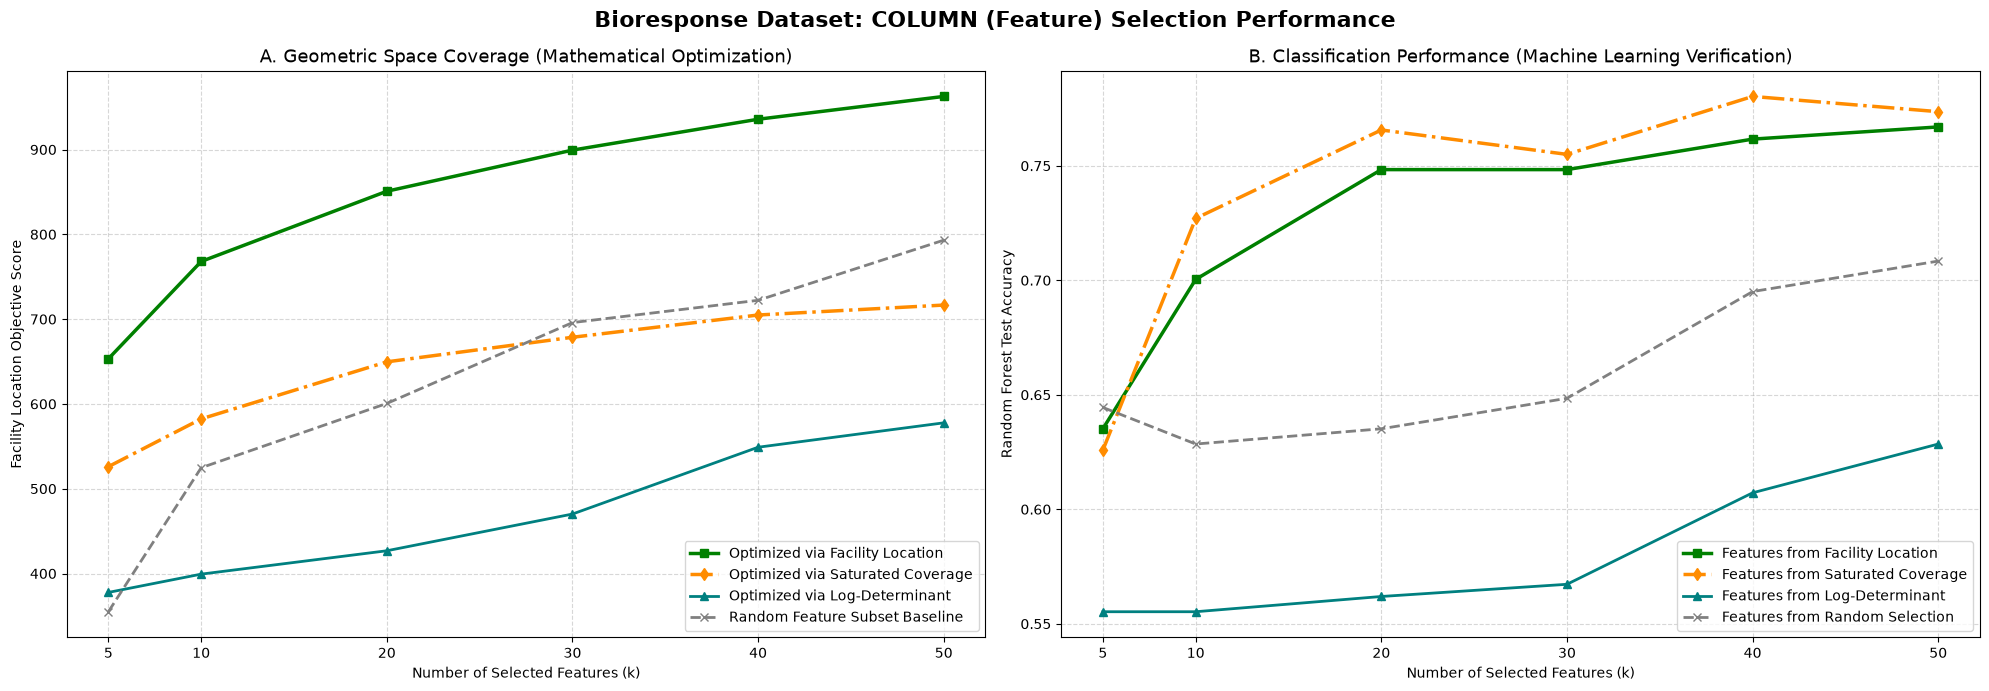


--- Uruchamianie walidacji ML dla WIERSZY (Instancje) ---
Starting greedy selection using facility_location (k=50)...
Step 1: Selected element 2074, Marginal Gain: 1549.2607
Step 10: Selected element 2981, Marginal Gain: 18.2283
Step 20: Selected element 2482, Marginal Gain: 8.2106
Step 30: Selected element 64, Marginal Gain: 6.1936
Step 40: Selected element 391, Marginal Gain: 4.5449
Step 50: Selected element 24, Marginal Gain: 3.3010
Starting greedy selection using saturated_coverage (k=50)...
Step 1: Selected element 2074, Marginal Gain: 1549.2607
Step 10: Selected element 6, Marginal Gain: 0.0000
Step 20: Selected element 16, Marginal Gain: 0.0000
Step 30: Selected element 26, Marginal Gain: 0.0000
Step 40: Selected element 36, Marginal Gain: 0.0000
Step 50: Selected element 46, Marginal Gain: 0.0000
Starting greedy selection using log_determinant (k=50)...
Step 1: Selected element 0, Marginal Gain: 0.6931
Step 10: Selected element 1029, Marginal Gain: 0.5757
Step 20: Selected ele

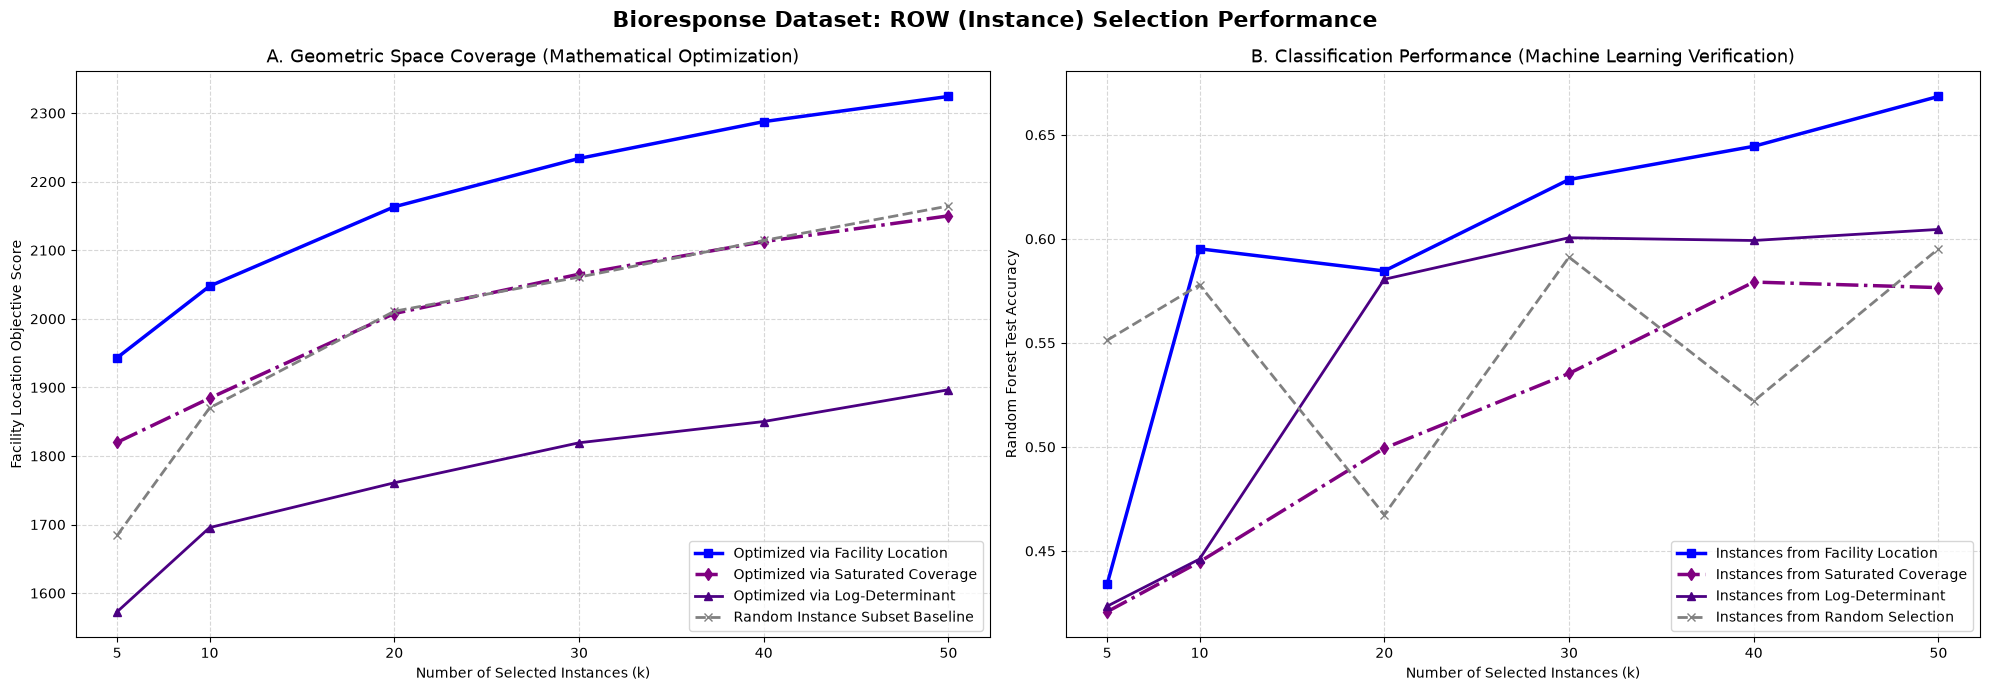

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

# Bezpieczne przygotowanie struktur NumPy (bazując na danych z Sekcji 1)
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else np.array(X_test)
y_train_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train).flatten()
y_test_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test).flatten()

budget_k = 50
k_milestones = [5, 10, 20, 30, 40, 50]


# =====================================================================
# %% CZĘŚĆ 1: KWALIFIKACJA I WALIDACJA DLA KOLUMN (FEATURES)
# =====================================================================
print("\n--- Uruchamianie walidacji ML dla KOLUMN (Cechy) ---")

# 1. Macierz podobieństwa dla cech (Pearson correlation)
bio_sim_matrix_cols = np.abs(np.corrcoef(X_train_np.T))
np.nan_to_num(bio_sim_matrix_cols, copy=False, nan=0.0)
np.fill_diagonal(bio_sim_matrix_cols, 1.0)
V_SIZE_COLS = bio_sim_matrix_cols.shape[0]

# 2. Poprawne wywołania funkcji greedy (z jawnymi keyword arguments)
selected_fl_cols, _ = greedy_submodular_maximization_2(V_SIZE_COLS, budget_k, bio_sim_matrix_cols, score_type='facility_location')
selected_sc_cols, _ = greedy_submodular_maximization_2(V_SIZE_COLS, budget_k, bio_sim_matrix_cols, score_type='saturated_coverage', alpha=1.0)
selected_ld_cols, _ = greedy_submodular_maximization_2(V_SIZE_COLS, budget_k, bio_sim_matrix_cols, score_type='log_determinant')

# Tablice na wyniki
scores_acc_fl_cols, scores_acc_sc_cols, scores_acc_ld_cols, scores_acc_rand_cols = [], [], [], []
scores_math_fl_cols, scores_math_sc_cols, scores_math_ld_cols, scores_math_rand_cols = [], [], [], []

for k_val in k_milestones:
    # Facility Location
    idx_fl = selected_fl_cols[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_fl], y_train_np)
    scores_acc_fl_cols.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_fl])))
    scores_math_fl_cols.append(facility_location_score(idx_fl, bio_sim_matrix_cols))
    
    # Saturated Coverage
    idx_sc = selected_sc_cols[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_sc], y_train_np)
    scores_acc_sc_cols.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_sc])))
    scores_math_sc_cols.append(facility_location_score(idx_sc, bio_sim_matrix_cols))
    
    # Log-Determinant
    idx_ld = selected_ld_cols[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_ld], y_train_np)
    scores_acc_ld_cols.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_ld])))
    scores_math_ld_cols.append(facility_location_score(idx_ld, bio_sim_matrix_cols))
    
    # Random Baseline
    np.random.seed(42 + k_val)
    idx_rand = np.random.choice(V_SIZE_COLS, k_val, replace=False).tolist()
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_rand], y_train_np)
    scores_acc_rand_cols.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_rand])))
    scores_math_rand_cols.append(facility_location_score(idx_rand, bio_sim_matrix_cols))

# Generowanie wykresu dla KOLUMN
fig_cols, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig_cols.suptitle("Bioresponse Dataset: COLUMN (Feature) Selection Performance", fontsize=16, fontweight='bold', y=0.98)

ax1.plot(k_milestones, scores_math_fl_cols, marker='s', label='Optimized via Facility Location', linewidth=2.5, color='green')
ax1.plot(k_milestones, scores_math_sc_cols, marker='d', label='Optimized via Saturated Coverage', linewidth=2.5, linestyle='-.', color='darkorange')
ax1.plot(k_milestones, scores_math_ld_cols, marker='^', label='Optimized via Log-Determinant', linewidth=2.0, color='teal')
ax1.plot(k_milestones, scores_math_rand_cols, marker='x', label='Random Feature Subset Baseline', linestyle='--', linewidth=2.0, color='gray')
ax1.set_title("A. Geometric Space Coverage (Mathematical Optimization)", fontsize=13)
ax1.set_xlabel("Number of Selected Features (k)")
ax1.set_ylabel("Facility Location Objective Score")
ax1.set_xticks(k_milestones)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')

ax2.plot(k_milestones, scores_acc_fl_cols, marker='s', label='Features from Facility Location', linewidth=2.5, color='green')
ax2.plot(k_milestones, scores_acc_sc_cols, marker='d', label='Features from Saturated Coverage', linewidth=2.5, linestyle='-.', color='darkorange')
ax2.plot(k_milestones, scores_acc_ld_cols, marker='^', label='Features from Log-Determinant', linewidth=2.0, color='teal')
ax2.plot(k_milestones, scores_acc_rand_cols, marker='x', label='Features from Random Selection', linestyle='--', linewidth=2.0, color='gray')
ax2.set_title("B. Classification Performance (Machine Learning Verification)", fontsize=13)
ax2.set_xlabel("Number of Selected Features (k)")
ax2.set_ylabel("Random Forest Test Accuracy")
ax2.set_xticks(k_milestones)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


# =====================================================================
# %% CZĘŚĆ 2: KWALIFIKACJA I WALIDACJA DLA WIERSZY (INSTANCES)
# =====================================================================
print("\n--- Uruchamianie walidacji ML dla WIERSZY (Instancje) ---")

# 1. Macierz podobieństwa dla instancji (Cosine Similarity)
bio_sim_matrix_rows = np.abs(cosine_similarity(X_train_np))
np.nan_to_num(bio_sim_matrix_rows, copy=False, nan=0.0)
np.fill_diagonal(bio_sim_matrix_rows, 1.0)
V_SIZE_ROWS = bio_sim_matrix_rows.shape[0]

# 2. Wywołania funkcji greedy dla wierszy
selected_fl_rows, _ = greedy_submodular_maximization_2(V_SIZE_ROWS, budget_k, bio_sim_matrix_rows, score_type='facility_location')
selected_sc_rows, _ = greedy_submodular_maximization_2(V_SIZE_ROWS, budget_k, bio_sim_matrix_rows, score_type='saturated_coverage', alpha=1.0)
selected_ld_rows, _ = greedy_submodular_maximization_2(V_SIZE_ROWS, budget_k, bio_sim_matrix_rows, score_type='log_determinant')

# Tablice na wyniki
scores_acc_fl_rows, scores_acc_sc_rows, scores_acc_ld_rows, scores_acc_rand_rows = [], [], [], []
scores_math_fl_rows, scores_math_sc_rows, scores_math_ld_rows, scores_math_rand_rows = [], [], [], []

for k_val in k_milestones:
    # Przy selekcji wierszy (instancji) trenujemy model na PODZBIORZE wierszy treningowych!
    
    # Facility Location
    idx_fl = selected_fl_rows[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[idx_fl, :], y_train_np[idx_fl])
    scores_acc_fl_rows.append(accuracy_score(y_test_np, clf.predict(X_test_np)))
    scores_math_fl_rows.append(facility_location_score(idx_fl, bio_sim_matrix_rows))
    
    # Saturated Coverage
    idx_sc = selected_sc_rows[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[idx_sc, :], y_train_np[idx_sc])
    scores_acc_sc_rows.append(accuracy_score(y_test_np, clf.predict(X_test_np)))
    scores_math_sc_rows.append(facility_location_score(idx_sc, bio_sim_matrix_rows))
    
    # Log-Determinant
    idx_ld = selected_ld_rows[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[idx_ld, :], y_train_np[idx_ld])
    scores_acc_ld_rows.append(accuracy_score(y_test_np, clf.predict(X_test_np)))
    scores_math_ld_rows.append(facility_location_score(idx_ld, bio_sim_matrix_rows))
    
    # Random Baseline
    np.random.seed(42 + k_val)
    idx_rand = np.random.choice(V_SIZE_ROWS, k_val, replace=False).tolist()
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[idx_rand, :], y_train_np[idx_rand])
    scores_acc_rand_rows.append(accuracy_score(y_test_np, clf.predict(X_test_np)))
    scores_math_rand_rows.append(facility_location_score(idx_rand, bio_sim_matrix_rows))

# Generowanie wykresu dla WIERSZY
fig_rows, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig_rows.suptitle("Bioresponse Dataset: ROW (Instance) Selection Performance", fontsize=16, fontweight='bold', y=0.98)

ax1.plot(k_milestones, scores_math_fl_rows, marker='s', label='Optimized via Facility Location', linewidth=2.5, color='blue')
ax1.plot(k_milestones, scores_math_sc_rows, marker='d', label='Optimized via Saturated Coverage', linewidth=2.5, linestyle='-.', color='purple')
ax1.plot(k_milestones, scores_math_ld_rows, marker='^', label='Optimized via Log-Determinant', linewidth=2.0, color='indigo')
ax1.plot(k_milestones, scores_math_rand_rows, marker='x', label='Random Instance Subset Baseline', linestyle='--', linewidth=2.0, color='gray')
ax1.set_title("A. Geometric Space Coverage (Mathematical Optimization)", fontsize=13)
ax1.set_xlabel("Number of Selected Instances (k)")
ax1.set_ylabel("Facility Location Objective Score")
ax1.set_xticks(k_milestones)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')

ax2.plot(k_milestones, scores_acc_fl_rows, marker='s', label='Instances from Facility Location', linewidth=2.5, color='blue')
ax2.plot(k_milestones, scores_acc_sc_rows, marker='d', label='Instances from Saturated Coverage', linewidth=2.5, linestyle='-.', color='purple')
ax2.plot(k_milestones, scores_acc_ld_rows, marker='^', label='Instances from Log-Determinant', linewidth=2.0, color='indigo')
ax2.plot(k_milestones, scores_acc_rand_rows, marker='x', label='Instances from Random Selection', linestyle='--', linewidth=2.0, color='gray')
ax2.set_title("B. Classification Performance (Machine Learning Verification)", fontsize=13)
ax2.set_xlabel("Number of Selected Instances (k)")
ax2.set_ylabel("Random Forest Test Accuracy")
ax2.set_xticks(k_milestones)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()